# Elastic Net (EN) on the MALL Extended 5-min Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the Elastic Net regression model on the MALL Extended 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The Elastic Net model extends the MHAR specification by combining an $L_1$-penalty and an $L_2$-penalty on the slope coefficients. Relative to ridge and LASSO, this allows the model to balance coefficient shrinkage and variable selection when the predictor set is broader and contains correlated macro-financial, cross-market, and euro-area spread variables.

The final MALL extended feature set used in this notebook is:

- `RVD`, `RVW`, `RVM`
- `VSTOXX`
- `CISS`
- `logEPU_1m_lag`
- `EURUSD_ret`
- `BRENT_ret`
- `NIKKEI_ret`, `NIKKEI_sq`
- `SP500_ret_lag`, `SP500_sq_lag`
- `M1W`, `M1M`
- `EURIBOR_OIS_CS`, `TERM_CS`

The coefficients are estimated by solving the regularized least squares problem:

$$
\min_{\beta_0,\beta}
\left\{
\sum_{t=1}^{T}
\left(RV_{t+1} - \beta_0 - X_t \beta\right)^2
+ \lambda \left[(1-\alpha)\sum_{j=1}^{p} \beta_j^2 + \alpha \sum_{j=1}^{p} |\beta_j|\right]
\right\},
$$

where $\lambda \geq 0$ is the overall regularization strength and $\alpha \in [0,1]$ controls the balance between ridge-like and lasso-like penalization.

The model is estimated using a rolling forecasting scheme with a fixed train/validation/test split (70/10/20). At each forecast origin, the optimal combination of regularization parameters is selected based on validation-set performance, and a one-day-ahead forecast is generated throughout the test period to evaluate out-of-sample accuracy.

## 1. Loading Data
Loading in data from the `MALL_extended_5min.csv` file.

In [25]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

# Load MALL extended dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_extended_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5489, 39)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,EURIBOR_3M,EURIBOR_3M_diff,EURO_10Y_SWAP,EURO_10Y_SWAP_diff,EURO_3M_OVERNIGHT_INDEX,EURO_3M_OVERNIGHT_INDEX_diff,EURIBOR_OIS_CS,TERM_CS,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,3.222,-0.012,4.160,-0.005,3.115,0.035,0.107,0.938,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,3.214,-0.008,4.162,0.002,3.100,-0.015,0.114,0.948,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,3.206,-0.008,4.160,-0.002,3.090,-0.010,0.116,0.954,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,3.196,-0.010,4.130,-0.030,3.095,0.005,0.101,0.934,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,3.193,-0.003,4.225,0.095,3.090,-0.005,0.103,1.032,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). The test set is forecasted one day ahead using a fixed-length rolling window.


In [9]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")


Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. Elastic Net


The Elastic Net regression model builds on the baseline HAR specification by introducing a combination of $L_1$- and $L_2$-penalties on the slope coefficients while allowing a broader MALL extended information set to enter the forecasting equation.

When $\alpha = 1$, Elastic Net reduces to LASSO, while values of $\alpha$ close to zero produce ridge-like penalization.

### 3.2 Feature Set Construction


In [14]:
# Define target and final MALL extended feature set
feature_cols = [
    "RVD", "RVW", "RVM",
    "VSTOXX", "CISS", "logEPU_1m_lag",
    "EURUSD_ret", "BRENT_ret",
    "NIKKEI_ret", "NIKKEI_sq",
    "SP500_ret_lag", "SP500_sq_lag",
    "M1W", "M1M",
    "EURIBOR_OIS_CS", "TERM_CS"
]

y = MALL["RV_target"].values
X_MALL = MALL[feature_cols].values

# Split into train, validation and test sets
X_train = X_MALL[:n_train]
X_val = X_MALL[n_train:n_train + n_val]
X_test = X_MALL[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

# Standardize each split using training-set parameters
X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Feature set:")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nTraining set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Mean of first 5 columns: {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"  Std of first 5 columns:  {X_train_scaled.std(axis=0)[:5].round(6)}")

Feature set:
  - RVD
  - RVW
  - RVM
  - VSTOXX
  - CISS
  - logEPU_1m_lag
  - EURUSD_ret
  - BRENT_ret
  - NIKKEI_ret
  - NIKKEI_sq
  - SP500_ret_lag
  - SP500_sq_lag
  - M1W
  - M1M
  - EURIBOR_OIS_CS
  - TERM_CS

Training set:   X=(3842, 16), y=(3842,)
Validation set: X=(548, 16), y=(548,)
Test set:       X=(1099, 16), y=(1099,)

Standardization check on training sample:
  Mean of first 5 columns: [ 0. -0. -0. -0.  0.]
  Std of first 5 columns:  [1. 1. 1. 1. 1.]


## 5. Elastic Net Model Specification and Hyperparameter Tuning


Alpha range: 1.00e-05 to 1.00e+02
l1_ratio grid: [0.01 0.05 0.1  0.2  0.3  0.4  0.5  0.7  0.9  1.  ]
Optimal alpha: 3.610419e-03
Optimal l1_ratio: 0.01
Validation MSE: 8.931007e-09
Non-zero coefficients at optimum: 5


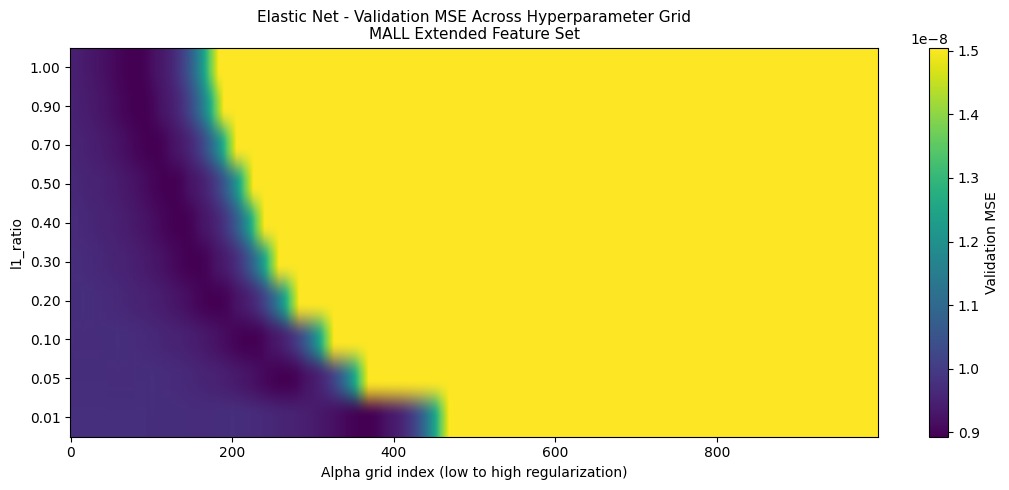

In [17]:
# Hyperparameter grids following the paper-style setup used in the thesis
alpha_grid = np.logspace(-5, 2, 1000)
l1_ratio_grid = np.array([0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 0.90, 1.00])

tuning_records = []
best_model = None
best_mse = np.inf
best_alpha = None
best_l1_ratio = None

for l1_ratio in l1_ratio_grid:
    for alpha in alpha_grid:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=100000)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        mse = np.mean((y_val - y_pred) ** 2)
        tuning_records.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "val_mse": mse,
            "nonzero": np.sum(np.abs(model.coef_) > 1e-12)
        })
        if mse < best_mse:
            best_mse = mse
            best_alpha = alpha
            best_l1_ratio = l1_ratio
            best_model = model

tuning_results = pd.DataFrame(tuning_records)
heatmap = tuning_results.pivot(index="l1_ratio", columns="alpha", values="val_mse")

print(f"Alpha range: {alpha_grid[0]:.2e} to {alpha_grid[-1]:.2e}")
print(f"l1_ratio grid: {np.round(l1_ratio_grid, 2)}")
print(f"Optimal alpha: {best_alpha:.6e}")
print(f"Optimal l1_ratio: {best_l1_ratio:.2f}")
print(f"Validation MSE: {best_mse:.6e}")
print(f"Non-zero coefficients at optimum: {np.sum(np.abs(best_model.coef_) > 1e-12)}")

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(heatmap.values, aspect="auto", origin="lower", cmap="viridis")
ax.set_title("Elastic Net - Validation MSE Across Hyperparameter Grid\nMALL Extended Feature Set", fontsize=11)
ax.set_xlabel("Alpha grid index (low to high regularization)")
ax.set_ylabel("l1_ratio")
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels([f"{v:.2f}" for v in heatmap.index])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation MSE")
plt.tight_layout()
plt.show()

## 6. Rolling Window Estimation and Forecasting


In [20]:
alpha_grid = np.logspace(-5, 2, 1000)
l1_ratio_grid = np.array([0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 0.90, 1.00])

window_size = n_train + n_val
forecasts_EN = []
dates_test = []
nonzero_path = []
alpha_path = []
l1_ratio_path = []

start_time = time.time()

for i in range(n_test):
    # Fixed-length rolling window with constant training and validation spans
    X_window = X_MALL[i:i + window_size]
    y_window = y[i:i + window_size]

    X_train_roll = X_window[:n_train]
    y_train_roll = y_window[:n_train]

    X_val_roll = X_window[n_train:]
    y_val_roll = y_window[n_train:]

    X_test_point = X_MALL[i + window_size].reshape(1, -1)

    # Standardize using the rolling training sample only
    X_mean_roll = X_train_roll.mean(axis=0)
    X_std_roll = X_train_roll.std(axis=0, ddof=0)
    X_std_roll = np.where(X_std_roll == 0, 1.0, X_std_roll)

    X_train_roll_scaled = (X_train_roll - X_mean_roll) / X_std_roll
    X_val_roll_scaled = (X_val_roll - X_mean_roll) / X_std_roll
    X_test_point_scaled = (X_test_point - X_mean_roll) / X_std_roll

    # Tune alpha and l1_ratio on the rolling validation set
    best_mse_roll = np.inf
    best_alpha_roll = None
    best_l1_ratio_roll = None

    for l1_ratio in l1_ratio_grid:
        for alpha in alpha_grid:
            model = ElasticNet(
                alpha=alpha,
                l1_ratio=l1_ratio,
                fit_intercept=True,
                max_iter=100000
            )
            model.fit(X_train_roll_scaled, y_train_roll)
            y_val_pred = model.predict(X_val_roll_scaled)
            mse = np.mean((y_val_roll - y_val_pred) ** 2)

            if mse < best_mse_roll:
                best_mse_roll = mse
                best_alpha_roll = alpha
                best_l1_ratio_roll = l1_ratio

    # Refit on the rolling training sample and forecast one day ahead
    model_final = ElasticNet(
        alpha=best_alpha_roll,
        l1_ratio=best_l1_ratio_roll,
        fit_intercept=True,
        max_iter=100000
    )
    model_final.fit(X_train_roll_scaled, y_train_roll)
    forecast = model_final.predict(X_test_point_scaled)[0]

    # Paper-consistent floor for negative forecasts
    min_rv_roll = y_train_roll.min()
    forecast = max(forecast, min_rv_roll)

    forecasts_EN.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    nonzero_path.append(np.sum(np.abs(model_final.coef_) > 1e-12))
    alpha_path.append(best_alpha_roll)
    l1_ratio_path.append(best_l1_ratio_roll)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_EN)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Average number of active predictors: {np.mean(nonzero_path):.2f}")
print(f"Average chosen alpha: {np.mean(alpha_path):.6e}")
print(f"Average chosen l1_ratio: {np.mean(l1_ratio_path):.4f}")
alpha_series = pd.Series(alpha_path)
l1_series = pd.Series(l1_ratio_path)
print(f"Boundary hits (min): {(alpha_series <= alpha_grid[0] * 1.001).sum()}")
print(f"Boundary hits (max): {(alpha_series >= alpha_grid[-1] * 0.999).sum()}")
print(f"Most common alpha: {alpha_series.mode()[0]:.2e}")
print(f"Most common l1_ratio: {l1_series.mode()[0]:.2f}")


  Day  100/1099 | Date: 2016-09-08 | Elapsed: 8.2 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 16.5 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 25.1 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 33.6 min
  Day  500/1099 | Date: 2018-04-04 | Elapsed: 42.0 min
  Day  600/1099 | Date: 2018-08-22 | Elapsed: 50.4 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 58.5 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 66.5 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 74.7 min
  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 82.7 min

Total estimation time: 90.7 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06
Average number of active predictors: 4.21
Average chosen alpha: 1.948034e-03
Average chosen l1_ratio: 0.6213
Boundary hits (min): 1
Boundary hits (max): 0
Most common alpha: 8.22e-03
Most common l1_ratio: 1.00


## 7. Save Forecasts


In [28]:
import os

# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Regularized Linear Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Regularized Linear Models"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_EN = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_EN
}, index=dates_test)

# --- Compute errors ---
errors_EN = results_EN["RV_actual"] - results_EN["RV_forecast"]
mse_EN = np.mean(errors_EN ** 2)

# --- Save forecasts ---
results_EN.to_csv(os.path.join(forecast_path, "forecasts_EN.csv"))

# --- Save MSE summary ---
mse_summary_EN = pd.DataFrame({
    "Model": ["EN"],
    "MSE": [mse_EN],
    "RMSE": [np.sqrt(mse_EN)],
    "MAE": [errors_EN.abs().mean()],
    "Mean_Error": [errors_EN.mean()]
}).set_index("Model")

mse_summary_EN.to_csv(os.path.join(mse_path, "mse_summary_EN.csv"))

# --- Print summary ---
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_EN)}")
print(f"Elastic Net test-set MSE: {mse_EN:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MALL Extended/Regularized Linear Models
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MALL Extended/Regularized Linear Models
Rows saved: 1099
Elastic Net test-set MSE: 5.144895e-08


## 8. Hyperparameter Path Visualisation


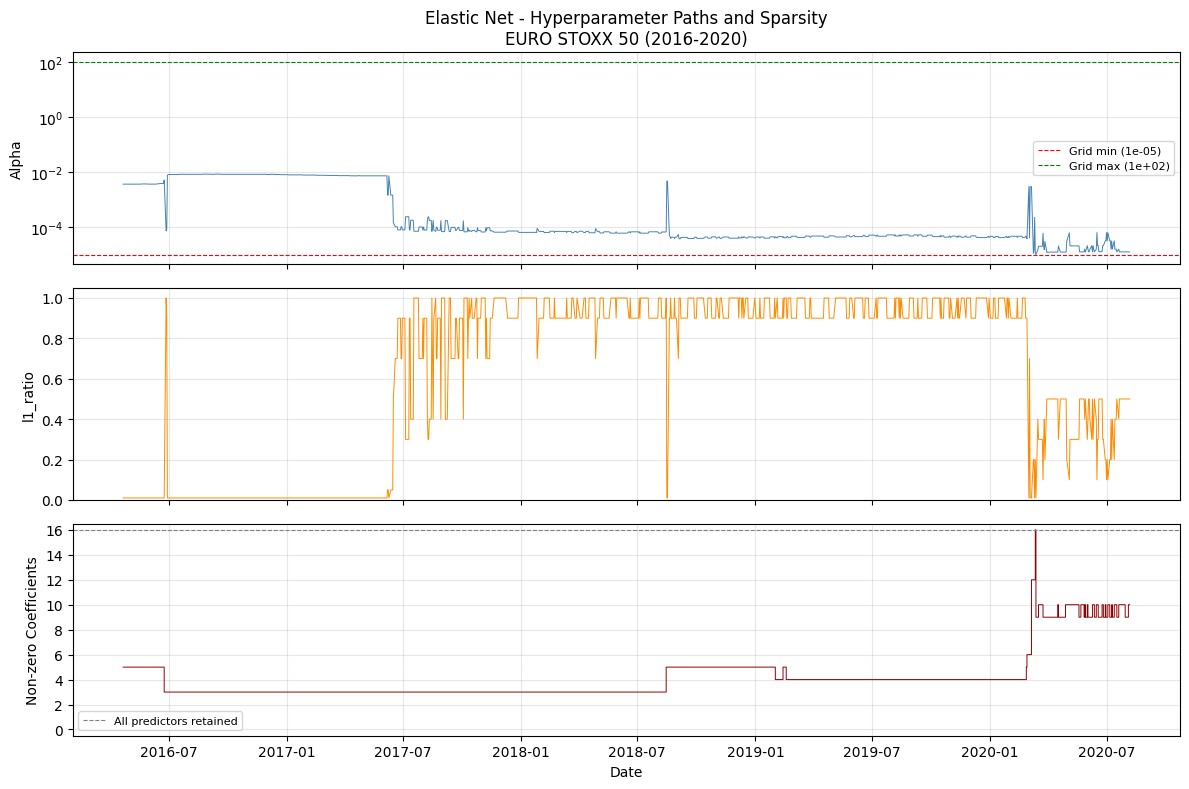

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# --- Alpha path ---
axes[0].semilogy(dates_test, alpha_path, color="steelblue", linewidth=0.7)
axes[0].axhline(y=alpha_grid[0], color="red", linestyle="--", linewidth=0.8, label=f"Grid min ({alpha_grid[0]:.0e})")
axes[0].axhline(y=alpha_grid[-1], color="green", linestyle="--", linewidth=0.8, label=f"Grid max ({alpha_grid[-1]:.0e})")
axes[0].set_ylabel("Alpha")
axes[0].set_title("Elastic Net - Hyperparameter Paths and Sparsity\nEURO STOXX 50 (2016-2020)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- l1_ratio path ---
axes[1].plot(dates_test, l1_ratio_path, color="darkorange", linewidth=0.7)
axes[1].set_ylabel("l1_ratio")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

# --- Sparsity path ---
axes[2].step(dates_test, nonzero_path, color="darkred", linewidth=0.7)
axes[2].set_ylabel("Non-zero Coefficients")
axes[2].set_xlabel("Date")
axes[2].set_yticks(list(range(0, len(feature_cols) + 1, 2)) + ([len(feature_cols)] if len(feature_cols) % 2 != 0 else []))
axes[2].set_ylim(-0.5, len(feature_cols) + 0.5)
axes[2].axhline(y=len(feature_cols), color="grey", linestyle="--", linewidth=0.8, label="All predictors retained")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Results


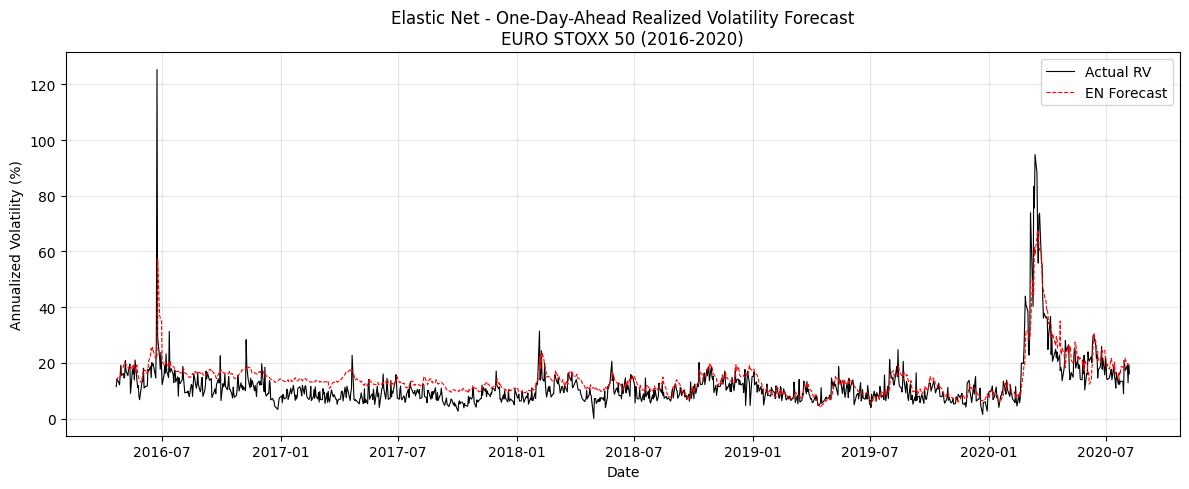


Summary of forecast errors:
Mean error:  -1.216135e-05
RMSE:        2.268236e-04
MAE:         5.395558e-05


In [34]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_EN["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_EN["RV_forecast"] * 252) * 100
}, index=results_EN.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="EN Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Elastic Net - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_EN["RV_actual"] - results_EN["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_EN):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")